In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

In [2]:
clean_metadata_df = pd.read_csv("../data/processed/clean_metadata.csv")

#Excluding baseline, since our goal is to determine which wheel was attacked using the attack files.
attack_meta_df = clean_metadata_df[clean_metadata_df["Scenario"] != "baseline"].copy()

print(f"Number of attack files: {len(attack_meta_df)}")
print(attack_meta_df["Scenario"].value_counts())

Number of attack files: 1798
Scenario
attack_rwa    600
attack_rwb    599
attack_rwc    599
Name: count, dtype: int64


In [3]:
# Using the same 26 features we used in the binary classification:

SELECTED_FEATURES = [
    "Q_B_I[0](1)", "Q_B_I[1](1)", "Q_B_I[2](1)", "Q_B_I[3](1)", 
"AttitudeError[0](rad)", "AttitudeError[1](rad)", "AttitudeError[2](rad)",
"AngVel_B_I[0](rad/sec)", "AngVel_B_I[1](rad/sec)", "AngVel_B_I[2](rad/sec)", "AngVelMag_B_I(rad/sec)",
"SensedWheelSpeed__RWA_A(rad/sec)", "SensedWheelSpeed__RWA_B(rad/sec)", "SensedWheelSpeed__RWA_C(rad/sec)",
"WheelCmd__RWA_A(N*m)", "WheelCmd__RWA_B(N*m)", "WheelCmd__RWA_C(N*m)",
"DesiredWheelCommand[0](N*m)", "DesiredWheelCommand[1](N*m)", "DesiredWheelCommand[2](N*m)",
"TotalTorqueRodCommand[0](A*m^2)", "TotalTorqueRodCommand[1](A*m^2)", "TotalTorqueRodCommand[2](A*m^2)",
"BField_B__TAM[0](T)", "BField_B__TAM[1](T)", "BField_B__TAM[2](T)"

]


In [4]:
train_meta, test_meta = train_test_split(attack_meta_df, test_size = 0.2, random_state=42, stratify=attack_meta_df["Scenario"])

In [5]:
print(f"Number of train files: {len(train_meta)}")
print(f"Number of test files: {len(test_meta)}")

print("\nTrain Scenario distribution:")
print(train_meta["Scenario"].value_counts())

print("\nTest Scenario distribution:")
print(test_meta["Scenario"].value_counts())

Number of train files: 1438
Number of test files: 360

Train Scenario distribution:
Scenario
attack_rwa    480
attack_rwc    479
attack_rwb    479
Name: count, dtype: int64

Test Scenario distribution:
Scenario
attack_rwb    120
attack_rwa    120
attack_rwc    120
Name: count, dtype: int64


In [6]:
ATTACK_START_TIME = 361 # confirmed earlier, all attacks start at this FswTime(sec)

def load_and_combine(meta_df):
    all_dfs = []
    for _, row in meta_df.iterrows():
        raw_path = Path("..") / row["data_file"].lstrip("./") # using "data_file" instead of "data_file_processed", since FswTime(sec) isn't in data_file_processed, so we need the raw csv for filtering.
        df = pd.read_csv(raw_path)

        #This filters out the baseline rows (result_label = baseline, i.e. the first 361 seconds) in the attack files, leaving only the attack rows, since our goal is to determine which wheel was attacked.
        df = df[df["FswTime(sec)"] >= ATTACK_START_TIME] 

        df = df[SELECTED_FEATURES + ["result_label"]] 

        all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)


In [7]:
train_df = load_and_combine(train_meta)
test_df = load_and_combine(test_meta)

print(f"train shape : {train_df.shape}")
print(f"test shape : {test_df.shape}")


train shape : (431400, 27)
test shape : (108000, 27)


In [8]:
print("Train label distribution:")
print(train_df["result_label"].value_counts())

print("\nTest label distribution:")
print(test_df["result_label"].value_counts())

Train label distribution:
result_label
RWA    144000
RWC    143700
RWB    143700
Name: count, dtype: int64

Test label distribution:
result_label
RWB    36000
RWA    36000
RWC    36000
Name: count, dtype: int64


In [9]:
FEATURE_COLS = [col for col in train_df.columns if col != "result_label"]

X_train = train_df[FEATURE_COLS]
y_train = train_df["result_label"]

X_test = test_df[FEATURE_COLS]
y_test = test_df["result_label"]

In [10]:
import re

def clean_column_names(columns):
    cleaned = [re.sub(r"[\[\]<>()]", "_", col) for col in columns]
    return cleaned

X_train.columns = clean_column_names(X_train.columns)
X_test.columns = clean_column_names(X_test.columns)

print(X_train.columns.to_list())

['Q_B_I_0__1_', 'Q_B_I_1__1_', 'Q_B_I_2__1_', 'Q_B_I_3__1_', 'AttitudeError_0__rad_', 'AttitudeError_1__rad_', 'AttitudeError_2__rad_', 'AngVel_B_I_0__rad/sec_', 'AngVel_B_I_1__rad/sec_', 'AngVel_B_I_2__rad/sec_', 'AngVelMag_B_I_rad/sec_', 'SensedWheelSpeed__RWA_A_rad/sec_', 'SensedWheelSpeed__RWA_B_rad/sec_', 'SensedWheelSpeed__RWA_C_rad/sec_', 'WheelCmd__RWA_A_N*m_', 'WheelCmd__RWA_B_N*m_', 'WheelCmd__RWA_C_N*m_', 'DesiredWheelCommand_0__N*m_', 'DesiredWheelCommand_1__N*m_', 'DesiredWheelCommand_2__N*m_', 'TotalTorqueRodCommand_0__A*m^2_', 'TotalTorqueRodCommand_1__A*m^2_', 'TotalTorqueRodCommand_2__A*m^2_', 'BField_B__TAM_0__T_', 'BField_B__TAM_1__T_', 'BField_B__TAM_2__T_']


In [11]:
# "y" is currently a string (RWA, RWB, RWC), but XGBoost's multi:softprob requires numeric labels.

label_map = {"RWA": 0, "RWB": 1, "RWC": 2}

y_train = y_train.map(label_map)
y_test = y_test.map(label_map)


In [12]:
model_multiclass = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

model_multiclass.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [13]:
y_pred = model_multiclass.predict(X_test)

In [14]:
#Invert label_map so the output shows RWA/RWB/RWC instead of 0/1/2:
inverse_label_map = {v: k for k, v in label_map.items()}
target_names = [inverse_label_map[i] for i in sorted(inverse_label_map)]


#Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="macro"))
print("Recall:", recall_score(y_test, y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print(f" \n Classification Report: \n {classification_report(y_test,y_pred, target_names=target_names)}")

Accuracy: 0.9932962962962963
Precision: 0.9933497653078708
Recall: 0.9932962962962962
F1 Score: 0.9933036409190809
 
 Classification Report: 
               precision    recall  f1-score   support

         RWA       1.00      0.99      0.99     36000
         RWB       0.98      1.00      0.99     36000
         RWC       1.00      0.99      1.00     36000

    accuracy                           0.99    108000
   macro avg       0.99      0.99      0.99    108000
weighted avg       0.99      0.99      0.99    108000



In [15]:
# Feature importance

importances = pd.Series(model_multiclass.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(10))

SensedWheelSpeed__RWA_A_rad/sec_    0.279707
SensedWheelSpeed__RWA_B_rad/sec_    0.268355
SensedWheelSpeed__RWA_C_rad/sec_    0.262668
AttitudeError_0__rad_               0.040769
AttitudeError_2__rad_               0.035015
AttitudeError_1__rad_               0.031148
DesiredWheelCommand_2__N*m_         0.014372
AngVel_B_I_2__rad/sec_              0.012334
AngVelMag_B_I_rad/sec_              0.007140
TotalTorqueRodCommand_2__A*m^2_     0.006079
dtype: float32


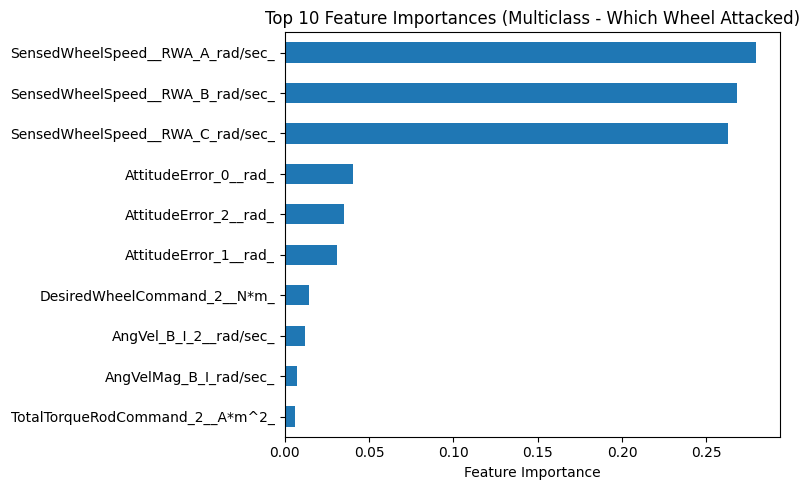

In [16]:
plt.figure(figsize=(8, 5))
importances.head(10).sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Multiclass - Which Wheel Attacked)")
plt.tight_layout()
plt.show()

In [17]:
# Overfitting check
from sklearn.metrics import roc_auc_score

y_train_pred = model_multiclass.predict(X_train)
y_train_proba = model_multiclass.predict_proba(X_train)

y_test_pred = y_pred
y_test_proba = model_multiclass.predict_proba(X_test)

metrics = {
    "Accuracy": (accuracy_score(y_train, y_train_pred), accuracy_score(y_test, y_test_pred)),
    "Precision": (precision_score(y_train, y_train_pred, average="macro"), precision_score(y_test, y_test_pred, average="macro")),
    "Recall": (recall_score(y_train, y_train_pred, average="macro"), recall_score(y_test, y_test_pred, average="macro")),
    "F1 Score": (f1_score(y_train, y_train_pred, average="macro"), f1_score(y_test, y_test_pred, average="macro")),
    "AUC": (roc_auc_score(y_train, y_train_proba, multi_class="ovr"), roc_auc_score(y_test, y_test_proba, multi_class="ovr")),
}

results_table = pd.DataFrame({
    "Train": [v[0] for v in metrics.values()],
    "Test": [v[1] for v in metrics.values()],
}, index=metrics.keys())

results_table["Difference"] = results_table["Train"] - results_table["Test"]
results_table.round(4)

,Train,Test,Difference
Accuracy,1.0,0.9933,0.0067
Precision,1.0,0.9933,0.0066
Recall,1.0,0.9933,0.0067
F1 Score,1.0,0.9933,0.0067
AUC,1.0,0.9999,0.0001


## Robustness Check: Predicting the Attacked Wheel Without Wheel Speed Sensors

Unlike the binary classification task, removing "primary affected" columns here follows a different logic. When the goal is simply to detect *whether* an attack is happening, it makes sense to question whether the model is overly dependent on a few directly-manipulated features, and to test performance without them.

However, once an attack has already been confirmed, the task shifts to identifying *which* wheel was attacked. In this context, `SensedWheelSpeed__RWA_A/B/C` being the most important features is expected and reasonable, since they are the core signals directly tied to each wheel. Treating them as columns to remove simply because the model relies on them, and labeling them "primary affected", doesn't really apply here the same way it did for the binary task.

That said, it is still worth testing a realistic scenario: what if the wheel speed sensors themselves failed or stopped reporting during an attack? To check how well the model could still identify the attacked wheel using only the remaining features, `SensedWheelSpeed__RWA_A/B/C` were removed and the model was retrained without them.

In [18]:
WHEEL_SPEED_COLUMNS = [
    "SensedWheelSpeed__RWA_A(rad/sec)", "SensedWheelSpeed__RWA_B(rad/sec)", "SensedWheelSpeed__RWA_C(rad/sec)"
]

WHEEL_SPEED_CLEANED = clean_column_names(WHEEL_SPEED_COLUMNS)  # cleaned again to avoid format issues in XGBoost

X_train_no_wheel_speed = X_train.drop(columns=WHEEL_SPEED_CLEANED)
X_test_no_wheel_speed = X_test.drop(columns=WHEEL_SPEED_CLEANED)

model_no_wheel_speed = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)


model_no_wheel_speed.fit(X_train_no_wheel_speed, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [19]:
# Predictions
y_pred_no_wheel_speed = model_no_wheel_speed.predict(X_test_no_wheel_speed)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_no_wheel_speed))
print("Precision:", precision_score(y_test, y_pred_no_wheel_speed, average="macro"))
print("Recall:", recall_score(y_test, y_pred_no_wheel_speed, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_no_wheel_speed, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_wheel_speed, target_names=target_names))

Accuracy: 0.85225
Precision: 0.8524602874847048
Recall: 0.8522500000000001
F1 Score: 0.8521074154146023

Classification Report:
              precision    recall  f1-score   support

         RWA       0.85      0.89      0.87     36000
         RWB       0.84      0.83      0.84     36000
         RWC       0.87      0.84      0.85     36000

    accuracy                           0.85    108000
   macro avg       0.85      0.85      0.85    108000
weighted avg       0.85      0.85      0.85    108000



In [20]:
importances_no_wheel_speed = pd.Series(model_no_wheel_speed.feature_importances_, index=X_train_no_wheel_speed.columns)
importances_no_wheel_speed = importances_no_wheel_speed.sort_values(ascending=False)
print(importances_no_wheel_speed.head(10))

TotalTorqueRodCommand_0__A*m^2_    0.133215
TotalTorqueRodCommand_2__A*m^2_    0.116783
TotalTorqueRodCommand_1__A*m^2_    0.111896
AngVelMag_B_I_rad/sec_             0.097667
DesiredWheelCommand_1__N*m_        0.046595
BField_B__TAM_0__T_                0.039582
DesiredWheelCommand_2__N*m_        0.038577
AngVel_B_I_1__rad/sec_             0.035194
AttitudeError_2__rad_              0.034653
BField_B__TAM_2__T_                0.034337
dtype: float32


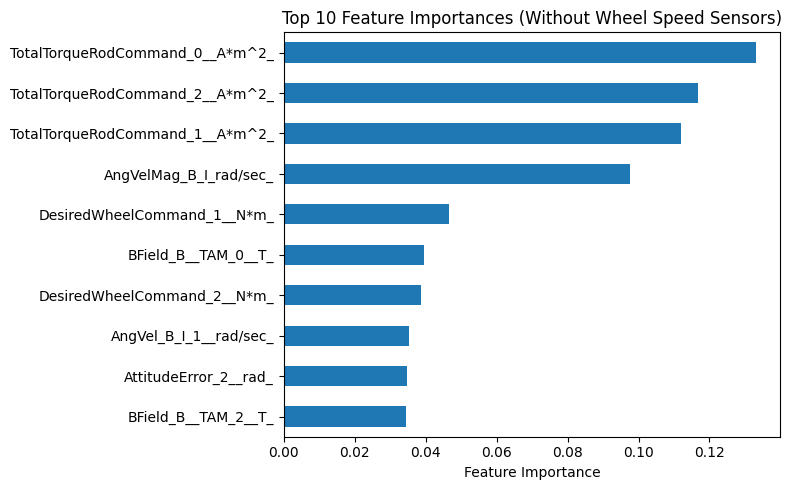

In [21]:
plt.figure(figsize=(8, 5))
importances_no_wheel_speed.head(10).sort_values(ascending=True).plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Without Wheel Speed Sensors)")
plt.tight_layout()
plt.show()

In [22]:
# Overfitting check - Model Without Wheel Speed Sensors

y_train_pred_no_wheel_speed = model_no_wheel_speed.predict(X_train_no_wheel_speed)
y_train_proba_no_wheel_speed = model_no_wheel_speed.predict_proba(X_train_no_wheel_speed)  # returns 3 columns for 3 classes

y_test_pred_no_wheel_speed = model_no_wheel_speed.predict(X_test_no_wheel_speed)
y_test_proba_no_wheel_speed = model_no_wheel_speed.predict_proba(X_test_no_wheel_speed)

metrics_no_wheel_speed = {
    "Accuracy": (
        accuracy_score(y_train, y_train_pred_no_wheel_speed),
        accuracy_score(y_test, y_test_pred_no_wheel_speed)
    ),
    "Precision": (
        precision_score(y_train, y_train_pred_no_wheel_speed, average="macro"),
        precision_score(y_test, y_test_pred_no_wheel_speed, average="macro")
    ),
    "Recall": (
        recall_score(y_train, y_train_pred_no_wheel_speed, average="macro"),
        recall_score(y_test, y_test_pred_no_wheel_speed, average="macro")
    ),
    "F1 Score": (
        f1_score(y_train, y_train_pred_no_wheel_speed, average="macro"),
        f1_score(y_test, y_test_pred_no_wheel_speed, average="macro")
    ),
    "AUC": (
        roc_auc_score(y_train, y_train_proba_no_wheel_speed, multi_class="ovr"),
        roc_auc_score(y_test, y_test_proba_no_wheel_speed, multi_class="ovr")
    ),
}

results_table_no_wheel_speed = pd.DataFrame({
    "Train": [v[0] for v in metrics_no_wheel_speed.values()],
    "Test": [v[1] for v in metrics_no_wheel_speed.values()],
}, index=metrics_no_wheel_speed.keys())

results_table_no_wheel_speed["Difference"] = results_table_no_wheel_speed["Train"] - results_table_no_wheel_speed["Test"]
results_table_no_wheel_speed.round(4)

,Train,Test,Difference
Accuracy,0.9289,0.8522,0.0766
Precision,0.9289,0.8525,0.0764
Recall,0.9289,0.8522,0.0766
F1 Score,0.9289,0.8521,0.0767
AUC,0.9903,0.9625,0.0278


### Overfitting Check – Model Without Wheel Speed Sensors

This drop in performance is expected: with `SensedWheelSpeed__RWA_A/B/C` removed, the model loses the most direct and informative signal for identifying which wheel is affected, and is forced to rely on more indirect, downstream features (`TotalTorqueRodCommand`, `AngVelMag_B_I`, `DesiredWheelCommand`, etc.).

The train/test gap also widens noticeably compared to the full-feature model (Accuracy: 0.0766, Precision: 0.0764, Recall: 0.0766, F1: 0.0767, AUC: 0.0278), and train performance itself drops to ~93% instead of ~100%. This pattern(lower train performance combined with a larger train/test gap) suggests the model is **underfitting** on the training data (it can no longer learn the task as cleanly without the wheel speed signals) while also showing **mild overfitting** relative to how well it fits the training set. In other words, without the primary wheel speed sensors, the remaining features still carry a meaningful, learnable signal (~85% accuracy is well above chance), but they are a much weaker substitute for identifying the attacked wheel.